         ts_s  loss_rate
0  1776704689   0.000000
1  1776704690   0.048246
2  1776704691   0.000000
3  1776704692   0.027778
4  1776704693   0.000000


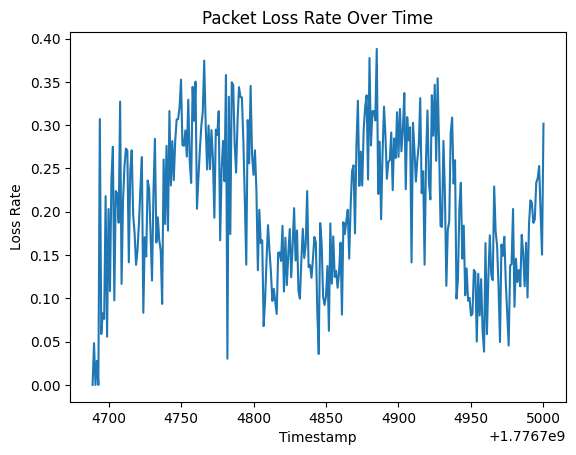

In [1]:
import pandas as pd

# Load the CSV
df = pd.read_csv("stats.csv")

# Compute loss rate: lost / (pkts + lost)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"])

# Group by timestamp and compute average loss rate
loss_rate_per_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

print(loss_rate_per_time.head())


loss_rate_per_time.to_csv("loss_rate_per_time.csv", index=False)

# Plot (optional)
import matplotlib.pyplot as plt
plt.plot(loss_rate_per_time["ts_s"], loss_rate_per_time["loss_rate"])
plt.xlabel("Timestamp")
plt.ylabel("Loss Rate")
plt.title("Packet Loss Rate Over Time")
plt.show()



# this zoom packet had the zoom running for some time 

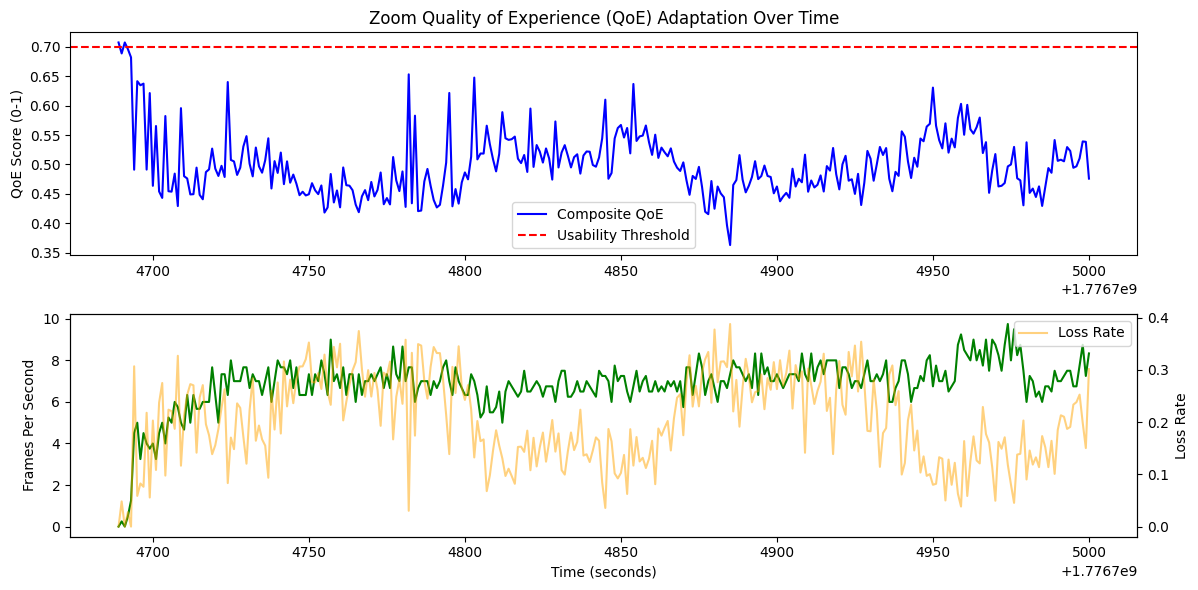


Correlation Analysis (Pearson):
qoe_score      1.000000
loss_rate     -0.828868
frames        -0.308350
mean_jitter   -0.049984
Name: qoe_score, dtype: float64


: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the metrics extracted from the Cabernet framework
df = pd.read_csv("stats.csv")

# 2. Compute individual Quality of Service (QoS) components
# Loss Rate: Avoid division by zero with fillna
df["loss_rate"] = (df["lost"] / (df["pkts"] + df["lost"])).fillna(0)

# 3. Calculate the Weighted QoE Model
# Based on Methodology: w1=0.4 (Loss), w2=0.3 (FPS), w3=0.3 (Jitter)
# Normalization: FPS target = 30, Jitter threshold = 40ms
w1, w2, w3 = 0.4, 0.3, 0.3

df["qoe_score"] = (
    w1 * (1 - df["loss_rate"]) +
    w2 * (df["frames"] / 30).clip(upper=1) + 
    w3 * (1 - (df["mean_jitter"] / 40)).clip(lower=0)
)

# 4. Group by timestamp to see session-wide adaptation
session_qoe = df.groupby("ts_s").agg({
    "qoe_score": "mean",
    "loss_rate": "mean",
    "frames": "mean",
    "mean_jitter": "mean"
}).reset_index()

# 5. Calculate Adaptation & Recovery Latency (Measurement Claim)
# Find when QoE drops below a 'usable' threshold (e.g., 0.7)
usable_threshold = 0.7
stressed = session_qoe[session_qoe["qoe_score"] < usable_threshold]

if not stressed.empty:
    start_stress = stressed["ts_s"].min()
    end_stress = stressed["ts_s"].max()
    
    # Recovery is defined as the time from the end of stress to stable quality
    recovery_data = session_qoe[session_qoe["ts_s"] > end_stress]
    recovered = recovery_data[recovery_data["qoe_score"] >= 0.85]
    
    if not recovered.empty:
        recovery_time = recovered["ts_s"].min() - end_stress
        print(f"Detected Recovery Latency: {recovery_time:.2f} seconds")

# 6. Visualization for the Paper
plt.figure(figsize=(12, 6))

# Primary Plot: QoE Score
plt.subplot(2, 1, 1)
plt.plot(session_qoe["ts_s"], session_qoe["qoe_score"], color='blue', label='Composite QoE')
plt.axhline(y=usable_threshold, color='r', linestyle='--', label='Usability Threshold')
plt.ylabel("QoE Score (0-1)")
plt.title("Zoom Quality of Experience (QoE) Adaptation Over Time")
plt.legend()

# Secondary Plot: FPS vs Loss (Correlation Analysis)
plt.subplot(2, 1, 2)
plt.plot(session_qoe["ts_s"], session_qoe["frames"], color='green', label='FPS')
plt.ylabel("Frames Per Second")
plt.xlabel("Time (seconds)")
plt.twinx()
plt.plot(session_qoe["ts_s"], session_qoe["loss_rate"], color='orange', alpha=0.5, label='Loss Rate')
plt.ylabel("Loss Rate")
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig("qoe_adaptation_analysis.png")
plt.show()

# 7. Export Correlation Table for Paper
correlation_matrix = session_qoe[["qoe_score", "loss_rate", "frames", "mean_jitter"]].corr()
correlation_matrix.to_csv("qoe_correlation_table.csv")
print("\nCorrelation Analysis (Pearson):")
print(correlation_matrix["qoe_score"])

Mode: Standard Video
Optimal Weights Found: Loss=0.7, FPS=0.1, Jitter=0.2
Maximum Model Accuracy: 93.49%


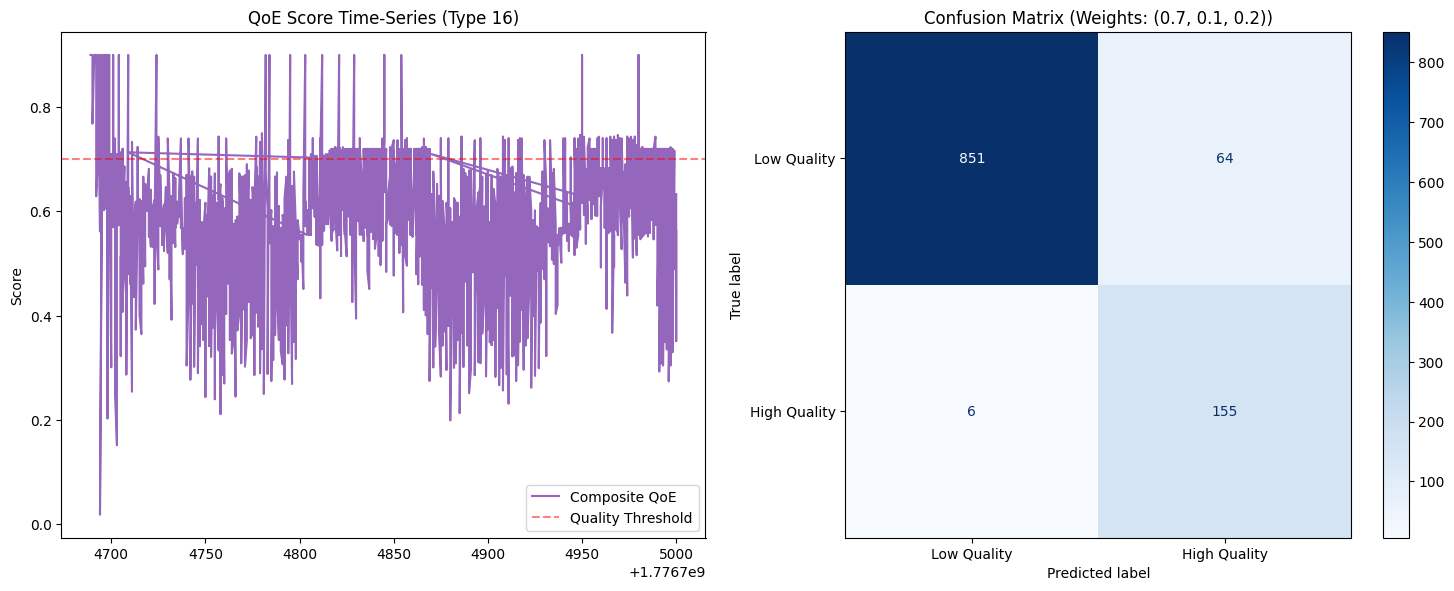


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Low Quality       0.99      0.93      0.96       915
High Quality       0.71      0.96      0.82       161

    accuracy                           0.93      1076
   macro avg       0.85      0.95      0.89      1076
weighted avg       0.95      0.93      0.94      1076



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from itertools import product

# 1. LOAD AND CLEAN DATA
df = pd.read_csv("stats.csv")
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. METRIC CALCULATION (Adaptive for Screenshare)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Detection of Screenshare (Media Type 13)
# Based on: https://dl.acm.org/doi/pdf/10.1145/3517745.3561414
df['is_screenshare'] = df['media_type'] == 13

# Apply conditional normalization targets
# Screenshare targets ~10 FPS; Video targets 30 FPS
df['fps_target'] = np.where(df['is_screenshare'], 10, 30)
df['fps_norm'] = (df['frames'] / df['fps_target']).clip(0, 1)

# Jitter threshold is 40ms for video, but often 60ms for screenshare
df['jitter_threshold'] = np.where(df['is_screenshare'], 60, 40)

if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000
    df['jitter_norm'] = (1 - (df['jitter_ms'] / df['jitter_threshold'])).clip(0, 1)

# 3. DEFINE GROUND TRUTH (The "Actual" Quality)
# Using your Stressed Network observations (Avg 7.48% loss mentioned in Overleaf)
df['actual_qoe_bin'] = np.where((df['loss_rate'] > 0.0748) | (df['frames'] < 5), 0, 1)

# 4. OPTIMIZATION: FIND BEST WEIGHTS
def calculate_accuracy(w1, w2, w3, data):
    # Dynamic calculation using the pre-normalized columns
    score = (w1 * (1 - data['loss_rate'])) + (w2 * data['fps_norm']) + (w3 * data['jitter_norm'])
    # Pred: 1 if Score > 0.7 (High), else 0 (Low)
    pred_bin = np.where(score > 0.7, 1, 0)
    return (pred_bin == data['actual_qoe_bin']).mean(), pred_bin

# Test combinations of weights that sum to 1.0
best_acc = 0
best_weights = (0.4, 0.3, 0.3)
weights_range = [np.round(x, 1) for x in np.linspace(0.1, 0.8, 8)]

for w1, w2 in product(weights_range, weights_range):
    w3 = np.round(1.0 - w1 - w2, 1)
    if w3 >= 0.1:
        acc, _ = calculate_accuracy(w1, w2, w3, df)
        if acc > best_acc:
            best_acc = acc
            best_weights = (w1, w2, w3)

print(f"Mode: {'Screen Share' if df['is_screenshare'].any() else 'Standard Video'}")
print(f"Optimal Weights Found: Loss={best_weights[0]}, FPS={best_weights[1]}, Jitter={best_weights[2]}")
print(f"Maximum Model Accuracy: {best_acc:.2%}")

# 5. GENERATE FINAL CONFUSION MATRIX
final_acc, y_pred = calculate_accuracy(*best_weights, df)
y_true = df['actual_qoe_bin']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Quality', 'High Quality'])

# 6. PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Optimized QoE over time
df['qoe_score'] = (best_weights[0] * (1 - df['loss_rate'])) + \
                  (best_weights[1] * df['fps_norm']) + \
                  (best_weights[2] * df['jitter_norm'])

ax1.plot(df['ts_s'], df['qoe_score'], color='#9467bd', label='Composite QoE')
ax1.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Quality Threshold')
ax1.set_title(f"QoE Score Time-Series (Type {'13' if df['is_screenshare'].any() else '16'})")
ax1.set_ylabel('Score')
ax1.legend()

# Plot Confusion Matrix
disp.plot(ax=ax2, cmap='Blues')
ax2.set_title(f'Confusion Matrix (Weights: {best_weights})')

plt.tight_layout()
plt.savefig('qoe_confusion_matrix_optimized.png')
plt.show()

# 7. SUMMARY
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Low Quality', 'High Quality']))